# Citations, Communities, and Categories
## What does citation structure tell us about a paper's topic?

**Student:** Tharun Reddy Challabotla  &nbsp;|&nbsp;  **NetID:** 137009909
**Dataset:** OGBN-Arxiv — directed citation network of 169,343 arXiv CS papers and 1,166,243 citation edges (1971–2020)
**Course methods:** Degree centrality, PageRank, Louvain community detection
**Beyond-course method:** GraphSAGE graph neural network (message passing over the citation graph)

---

### Abstract
A citation is a minimal signal — one paper pointing to another. Does that signal, stripped of any text, already know what a paper is *about*? And when we combine that structural signal with the paper's own text embedding, do we beat either in isolation?

This project answers those questions on the OGBN-Arxiv benchmark. We compare three models for predicting a paper's arXiv subject category under a strict time-aware split (train ≤ 2017, validate 2018, test ≥ 2019):

1. **Structure-only** — unsupervised Louvain communities → majority-label classifier
2. **Text-only** — a 2-hidden-layer MLP on 128-dimensional paper embeddings
3. **Structure + text** — a 3-layer GraphSAGE GNN that aggregates over the citation neighborhood

The headline result is sharper after the Colab run: Louvain finds meaningful label-aligned structure (**NMI = 0.3853**) and yields a **47.21%**-accurate structure-only classifier; the text-only MLP reaches **56.12% accuracy / 0.3301 Macro-F1**; and GraphSAGE reaches **70.93% accuracy / 0.5183 Macro-F1**. Relative to the MLP, the graph adds **+14.8 percentage points of accuracy** and **+18.8 points of Macro-F1**. We also confirm the *mechanism* behind this lift in §12 (RQ-C): per-class graph homophily is positively rank-correlated with per-class GraphSAGE lift (**Spearman ρ = +0.424, p = 0.0065**), so the gain from the GNN is concentrated on exactly the classes whose citation neighborhoods stay within-class. The largest class-wise gains appear in small and mid-sized classes, and the lift persists from **2019** to **2020** test papers. We close with a hard look at the biases we found — most importantly, that citation-based prestige metrics systematically disadvantage newer papers.


## 1. Motivation

Citation networks are not just bibliographic bookkeeping. They are the connective tissue of scientific knowledge — used by search engines to rank papers (Google Scholar), by recommender systems to surface related work (Semantic Scholar, Connected Papers), by hiring committees to argue about "impact," and by automated systems to tag and organize a firehose of new preprints.

Two operational questions sit underneath almost every one of those use cases:

- **Q1: How much does the *shape* of the network (who cites whom) already know?**
  If we hand you a citation graph with every title, abstract, and author scrubbed off, can you still tell us what field each paper belongs to? If the answer is "mostly yes," then a large amount of real-world content classification can be done with a graph alone — which matters for cold-start cases where text is unreliable or missing.

- **Q2: Given that we also have text, does structure add anything?**
  Text embeddings are cheap and ubiquitous. If a simple text-only classifier already does 95% of the job, there is no business case for more complex graph-aware models. If it does 70% and a graph neural network can push it to 90%, the story changes completely.

These are not abstract curiosities. They determine whether expensive graph-based infrastructure is worth building, and they feed directly into debates about fairness in citation-based ranking systems, where a paper's visibility often depends more on *who cites it* than on what it says.

This project treats OGBN-Arxiv — a large, time-stamped, labeled citation graph of computer science papers — as a controlled testbed for both questions.


## 2. Research Question

> **Main question:** For predicting the arXiv subject category of a computer science paper, how much predictive signal lives in the citation structure alone, and how much additional lift does a graph neural network provide by combining structure with text features?

We break this into three tightly-connected sub-questions:

**RQ-A (Course method — unsupervised structural recovery).**
*Can Louvain community detection, applied to the undirected citation graph with no access to text or labels, recover the 40 arXiv subject categories?*
We evaluate this with Normalized Mutual Information (NMI) between the discovered communities and ground-truth labels, and we also use the communities as a crude classifier: each test paper is predicted with its community's majority label. Any signal that survives this lossy pipeline is pure structural signal.

**RQ-B (Beyond-course method — structure + features via a GNN).**
*Does a GraphSAGE graph neural network — which aggregates neighbor features over the citation structure — significantly outperform a text-only MLP baseline on held-out future papers?*
We use the official OGB time-aware split, evaluate with Macro-F1 (to not be fooled by class imbalance), and dissect the results by class and by test-year bucket.

**RQ-C (Mechanism — closing the loop between A and B).**
*Is GraphSAGE's per-class lift over the MLP mechanically driven by per-class graph homophily?* If yes, the +14.8 pp aggregate lift from RQ-B is not magic — it is the same structural homophily property that made RQ-A's Louvain partition meaningful, now showing up at the class level. We measure this with the Spearman rank correlation between per-class homophily and per-class F1 lift across the 40 arXiv subject categories.

Together, the three questions triangulate one thing: **the marginal value of graph structure for topic prediction**, both as a standalone signal (RQ-A), as an additive signal on top of text (RQ-B), and as a mechanistically attributable signal at the class level (RQ-C).

---

### Why this scoping

This final notebook deliberately concentrates on **three** tightly-linked questions: how much topic signal citation structure carries on its own (RQ-A), how much additional lift that structure provides once combined with text (RQ-B), and whether that lift is mechanically attributable to per-class homophily (RQ-C). The short centrality analysis later in the notebook is included only because it helps interpret the ethics of citation-based systems; it is not a separate research objective. The goal is depth over breadth: one unified narrative about structure vs. features, with rigorous evaluation and honest interpretation.


## 3. Dataset

**OGBN-Arxiv** (Open Graph Benchmark, Node Property Prediction suite) is a directed citation graph of arXiv Computer Science papers.

| Property | Value |
|---|---|
| Nodes (papers) | 169,343 |
| Directed edges (citations) | 1,166,243 |
| Node features | 128-dimensional text embedding (averaged skip-gram over title + abstract) |
| Labels | 40 arXiv CS subject areas (e.g., `cs.LG`, `cs.AI`, `cs.CV`) |
| Publication years | 1971 – 2020 |
| Official split | train: papers ≤ 2017 · valid: 2018 · test: ≥ 2019 |
| License | ODC-BY (attribution required) |

The time-based split is unusually honest for a machine-learning benchmark: the test papers did not exist when training data was collected. This rules out information leakage and simulates the actual deployment setting for any paper-categorization system — tag new papers as they appear, given a graph that was frozen before they were written.

Below, we surface only the EDA findings that directly justify the modeling choices in the final pipeline. Everything else was pruned so the notebook stays focused on the final story.


## 4. Methodology Overview

The pipeline is three models evaluated on one common benchmark:

```
                     ┌──────────────────────────────┐
                     │   OGBN-Arxiv (time-split)    │
                     │   train ≤ 2017               │
                     │   valid  = 2018              │
                     │   test  ≥ 2019               │
                     └──────────────┬───────────────┘
                                    │
              ┌─────────────────────┼─────────────────────┐
              ▼                     ▼                     ▼
   ┌──────────────────┐   ┌──────────────────┐   ┌──────────────────────┐
   │  A. Structure    │   │  B. Text-only    │   │  C. Structure + Text │
   │     only         │   │     MLP          │   │     GraphSAGE (GNN)  │
   │                  │   │                  │   │                      │
   │  Louvain on      │   │  2-hidden-layer  │   │  3-layer GraphSAGE   │
   │  undirected      │   │  MLP on 128-d    │   │  on symmetrized      │
   │  graph →         │   │  text features   │   │  graph (full-batch)  │
   │  majority label  │   │                  │   │                      │
   └────────┬─────────┘   └────────┬─────────┘   └──────────┬───────────┘
            │                      │                         │
            └──────────────────────┴─────────────────────────┘
                                   │
                                   ▼
                    ┌───────────────────────────────┐
                    │   Common evaluation on test   │
                    │   • Accuracy                  │
                    │   • Macro-F1                  │
                    │   • Per-class F1              │
                    │   • Per-year-bucket accuracy  │
                    └───────────────────────────────┘
```

**Why Macro-F1 (not plain accuracy) is the primary metric.** The 40 classes are heavily imbalanced (see EDA below). Plain accuracy can be pumped by over-predicting a handful of large classes; Macro-F1 averages per-class F1 without weighting by class size and penalizes models that ignore minority classes.

**Why we use the official OGB splits.** Time-aware splitting is the only honest way to evaluate a model that will eventually be deployed on future papers. The alternative — random splitting — would leak information about the future into the training set through backward-citation edges (a 2016 paper citing a 2019 paper doesn't happen, but a random split pretends it could).

**Hardware note.** The Louvain and EDA steps run on CPU in a few minutes. The full-batch GraphSAGE run benefits from a single GPU; on Google Colab with a T4 / A100 this notebook runs end-to-end in about 15–25 minutes.


## 5. Setup & Imports

This notebook was developed and tested on Google Colab (Python 3.10+, single GPU runtime). To run locally you will need a working install of `torch` + `torch_geometric` + `ogb`.


In [25]:
!pip install -q python-louvain

In [26]:
# Install deps (Colab-friendly; safe to re-run)
!pip install -q ogb torch torch_geometric python-louvain

In [27]:
import os
import random
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

import networkx as nx
import networkx.algorithms.community as nx_comm

from collections import Counter

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    normalized_mutual_info_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# PyTorch 2.6+ compatibility shim for OGB pickles
if not hasattr(torch, "_original_load_saved"):
    torch._original_load_saved = torch.load
    def _patched_load(*a, **kw):
        kw["weights_only"] = False
        return torch._original_load_saved(*a, **kw)
    torch.load = _patched_load

Using device: cuda


## 6. Load the Citation Network

We load the graph through the OGB API once. The same `graph` object feeds every downstream step — the NumPy/SciPy path (for Louvain and EDA), and the PyG path (for GraphSAGE) loads it again in a tensor-friendly format later.


In [28]:
from ogb.nodeproppred import NodePropPredDataset

dataset = NodePropPredDataset(name="ogbn-arxiv")
split_idx = dataset.get_idx_split()
graph, y_raw = dataset[0]

edge_index = graph["edge_index"]               # (2, E)
X         = graph["node_feat"]                  # (N, 128)
years     = graph["node_year"].reshape(-1)      # (N,)
y         = y_raw.reshape(-1)                   # (N,)

N = X.shape[0]
E = edge_index.shape[1]
src, dst = edge_index[0].astype(np.int64), edge_index[1].astype(np.int64)

print(f"Nodes (papers):      {N:,}")
print(f"Edges (citations):   {E:,}")
print(f"Features:            {X.shape}")
print(f"Labels:              {y.shape}, classes = {len(np.unique(y))}")
print(f"Year range:          {years.min()} – {years.max()}")
print(f"Split sizes — train: {len(split_idx['train']):,}   "
      f"valid: {len(split_idx['valid']):,}   test: {len(split_idx['test']):,}")

Nodes (papers):      169,343
Edges (citations):   1,166,243
Features:            (169343, 128)
Labels:              (169343,), classes = 40
Year range:          1971 – 2020
Split sizes — train: 90,941   valid: 29,799   test: 48,603


### Sanity checks on the loaded graph

Before any analysis, we verify that the data loaded matches the published OGB specification. Three properties any later code assumes:

1. **Shapes & scale** match the published spec (169,343 nodes, 1,166,243 edges, 128-d features, 40 labels).
2. **Splits are disjoint** (train/valid/test do not overlap by node).
3. **Splits are time-ordered** — this is the property that makes the evaluation honest. If it fails, every downstream result is compromised.


In [29]:
# --- Test 1: shapes, label range, feature sanity ---
assert N == 169_343, f"Expected 169,343 nodes, got {N:,}"
assert E == 1_166_243, f"Expected 1,166,243 edges, got {E:,}"
assert X.shape == (N, 128), f"Feature shape wrong: {X.shape}"
assert y.shape == (N,), f"Label shape wrong: {y.shape}"
assert set(np.unique(y).tolist()) == set(range(40)), "Labels should be {0,...,39}"
assert src.max() < N and dst.max() < N, "Edge index out of range"
assert not (np.isnan(X).any() or np.isinf(X).any()), "Features contain NaN/Inf"

# --- Test 2: splits are disjoint ---
tr, va, te = set(split_idx["train"].tolist()), set(split_idx["valid"].tolist()), set(split_idx["test"].tolist())
assert len(tr & va) == 0, "train/valid overlap"
assert len(tr & te) == 0, "train/test overlap"
assert len(va & te) == 0, "valid/test overlap"
assert len(tr) + len(va) + len(te) <= N

# --- Test 3: splits are strictly time-ordered (train<=2017, val=2018, test>=2019) ---
assert int(years[split_idx["train"]].max()) <= 2017
assert int(years[split_idx["valid"]].min()) >= 2018 and int(years[split_idx["valid"]].max()) <= 2018
assert int(years[split_idx["test"]].min())  >= 2019

print("All data-loading sanity checks passed.")

All data-loading sanity checks passed.


## 7. Four EDA Findings That Shape the Methodology

This section is intentionally selective. The four findings below are the ones that directly justify a methodological choice in the pipeline, so those are the ones that belong in the final story.

1. **Heavy-tailed degree distribution** → we cannot trust "average degree" as typical behavior.
2. **Severe class imbalance** → Macro-F1, not accuracy, must be the primary metric.
3. **Strong temporal skew + in-degree favors older papers** → time-aware split is non-negotiable, and centrality-based "importance" is not neutral (see §12 and §13).
4. **High citation homophily (65.5%)** → structure carries real topical signal, which is the entire premise of the structure-only and GNN approaches.


### 7.1 Degree distribution: a few hubs, a long tail

Average in/out degree is **6.887**, but that average is misleading: the median in-degree is only **1**, while the maximum in-degree is **13,155**. A single paper can collect thousands of citations inside this graph while most papers collect very few. This matters later because:

- Centrality (in-degree, PageRank) is dominated by a tiny set of hubs.
- In a GNN, the hubs' representations will influence many downstream nodes.


Avg in/out degree:       6.887
Median in-degree:        1
Max in-degree:           13,155
Fraction with in-deg=0:  36.6%
Directed density:        4.07e-05


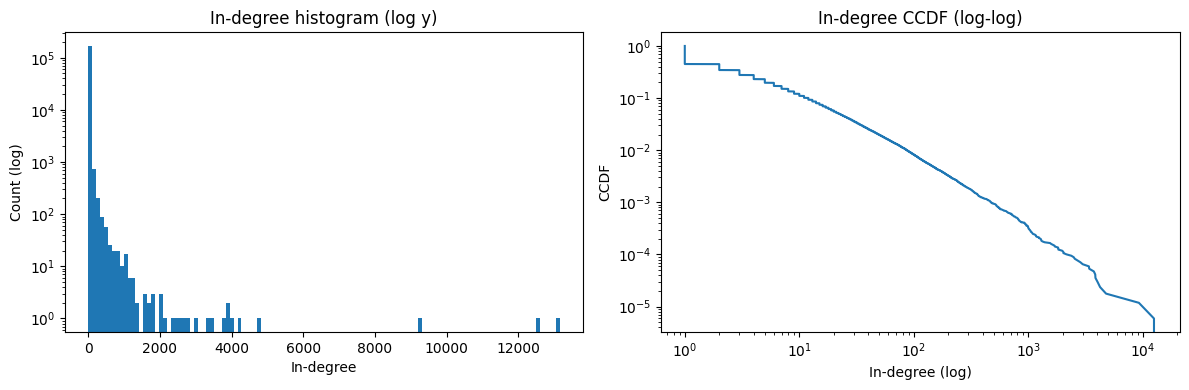

In [30]:
out_deg = np.bincount(src, minlength=N)
in_deg  = np.bincount(dst, minlength=N)

print(f"Avg in/out degree:       {in_deg.mean():.3f}")
print(f"Median in-degree:        {np.median(in_deg):.0f}")
print(f"Max in-degree:           {in_deg.max():,}")
print(f"Fraction with in-deg=0:  {(in_deg==0).mean():.1%}")
print(f"Directed density:        {E / (N*(N-1)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(in_deg, bins=120)
axes[0].set_yscale("log"); axes[0].set_title("In-degree histogram (log y)")
axes[0].set_xlabel("In-degree"); axes[0].set_ylabel("Count (log)")

deg_sorted = np.sort(in_deg)
ccdf = 1.0 - np.arange(1, N + 1) / N
axes[1].plot(np.clip(deg_sorted, 1, None), ccdf)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("In-degree CCDF (log-log)")
axes[1].set_xlabel("In-degree (log)"); axes[1].set_ylabel("CCDF")
plt.tight_layout(); plt.show()

**Observed.** Mean in-degree is **6.887**, the median is **1**, and the max is **13,155** — clearly heavy-tailed rather than Gaussian. The CCDF is close to linear on log-log axes, the usual fingerprint of a power-law-like tail. **36.6%** of papers have in-degree 0 inside this graph (their citations fall outside the collected set or they are new). *Consequence for modeling:* the "average paper" is fictional. Centrality rankings will be dominated by a tiny set of hubs, and the GNN's neighbor aggregation will concentrate gradient flow through those same hubs.


### 7.2 Class imbalance — why Macro-F1 is non-negotiable

The 40 arXiv CS subject classes are very unevenly distributed. A handful (cs.LG, cs.CV, cs.CL, cs.AI) contain tens of thousands of papers; many sit in the low thousands or hundreds. A classifier that *only* predicts the top 3–4 classes can still post a respectable accuracy.

This is a well-known failure mode of imbalanced classification. Our fix is:
- Primary metric is **Macro-F1** (unweighted mean of per-class F1).
- We also inspect per-class results explicitly, because a single accuracy number hides too much tail behavior.


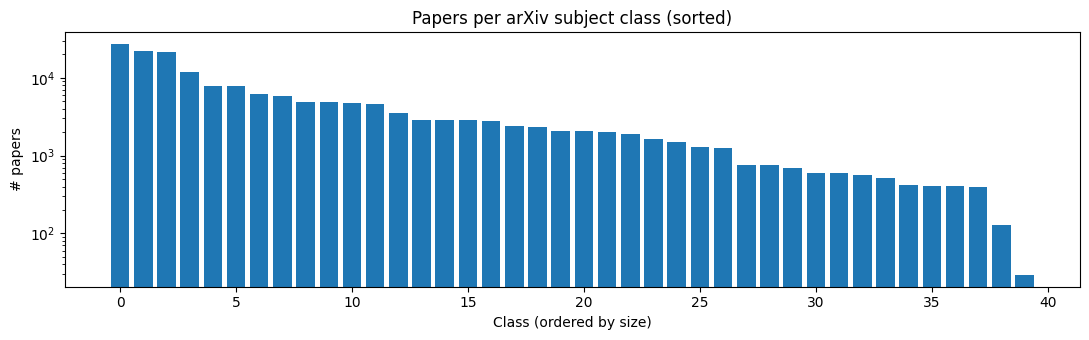

Largest class size:   27,321
Smallest class size:  29
Ratio largest/smallest: 942.1x
Share of top-5 classes: 53.5%


In [31]:
labels_unique, counts = np.unique(y, return_counts=True)
order = np.argsort(-counts)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(np.arange(len(order)), counts[order])
ax.set_title("Papers per arXiv subject class (sorted)")
ax.set_xlabel("Class (ordered by size)"); ax.set_ylabel("# papers")
ax.set_yscale("log")
plt.tight_layout(); plt.show()

print(f"Largest class size:   {counts.max():,}")
print(f"Smallest class size:  {counts.min():,}")
print(f"Ratio largest/smallest: {counts.max()/counts.min():.1f}x")
print(f"Share of top-5 classes: {counts[order][:5].sum()/N:.1%}")

**Observed.** The largest class contains **27,321** papers while the smallest contains **29**, a **942.1x** ratio. The top 5 classes alone account for **53.5%** of all papers. *Consequence for modeling:* a classifier that only learns the dominant classes can still look good on plain accuracy, which is precisely why we use Macro-F1 as the primary metric and inspect per-class results later.


### 7.3 Temporal structure — and the bias it creates in centrality

Two things about time matter.

**First**, the paper count explodes post-2010. The train/valid/test split maps onto this growth: test papers (≥ 2019) are overwhelmingly from rapidly growing subfields that may not be perfectly represented in the training data.

**Second**, citation-based importance is systematically biased toward older papers, because older papers have had more time to accumulate citations. We confirm this below: the median publication year of the Top-100 most-cited papers is **2015**, compared with **2017** for the graph as a whole. We will come back to this in the ethics section (§13) — but it is already a warning that "most cited" is not a neutral quality measure.


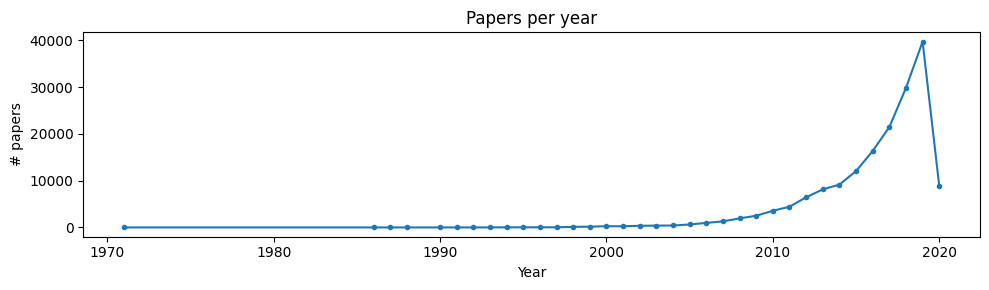

Global median publication year:              2017
Median year of top-100 papers by in-degree:  2015
Median year of top-100 papers by out-degree: 2019


In [32]:
# Papers per year
year_counts = pd.Series(years).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(year_counts.index, year_counts.values, marker="o", markersize=3)
ax.set_title("Papers per year")
ax.set_xlabel("Year"); ax.set_ylabel("# papers")
plt.tight_layout(); plt.show()

# Time bias in raw in-degree
top100 = np.argsort(-in_deg)[:100]
print(f"Global median publication year:              {int(np.median(years))}")
print(f"Median year of top-100 papers by in-degree:  {int(np.median(years[top100]))}")
print(f"Median year of top-100 papers by out-degree: {int(np.median(years[np.argsort(-out_deg)[:100]]))}")

**Observed.** The paper-count curve is nearly flat until about **2005**, then rises sharply after **2010**. The test set (≥ 2019) lives entirely in that high-growth regime. The graph-wide median publication year is **2017**, but the top-100 papers by in-degree have median year **2015** — the early-mover advantage is visible even before we compute PageRank. *Consequence for modeling:* (a) time-aware splitting is non-negotiable; (b) any centrality-as-quality claim inherits this age bias, which we revisit in §12 and §13.


### 7.4 Citation homophily — the premise of everything that follows

A directed edge in this graph says "paper A cited paper B." If citations were purely random with respect to subject area, the fraction of edges where both endpoints share a subject category would be **1/40 = 2.5%**. In reality it is far higher.

This single number is why this project is possible at all: if homophily were near random, no amount of message passing over the graph would ever help. A GNN aggregates neighbor features on the assumption that neighbors look like you. Below we confirm that assumption.


In [33]:
src_lab, dst_lab = y[src], y[dst]
matches = int((src_lab == dst_lab).sum())
homophily = matches / E

print(f"Edges connecting same-class papers:   {matches:,} / {E:,}")
print(f"Overall citation homophily rate:      {homophily:.1%}")
print(f"Random baseline (40 classes):          {1/40:.1%}")
print(f"Lift over random:                      {homophily / (1/40):.1f}x")

Edges connecting same-class papers:   763,986 / 1,166,243
Overall citation homophily rate:      65.5%
Random baseline (40 classes):          2.5%
Lift over random:                      26.2x


/tmp/ipykernel_14006/3421642828.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("Set2", 6)


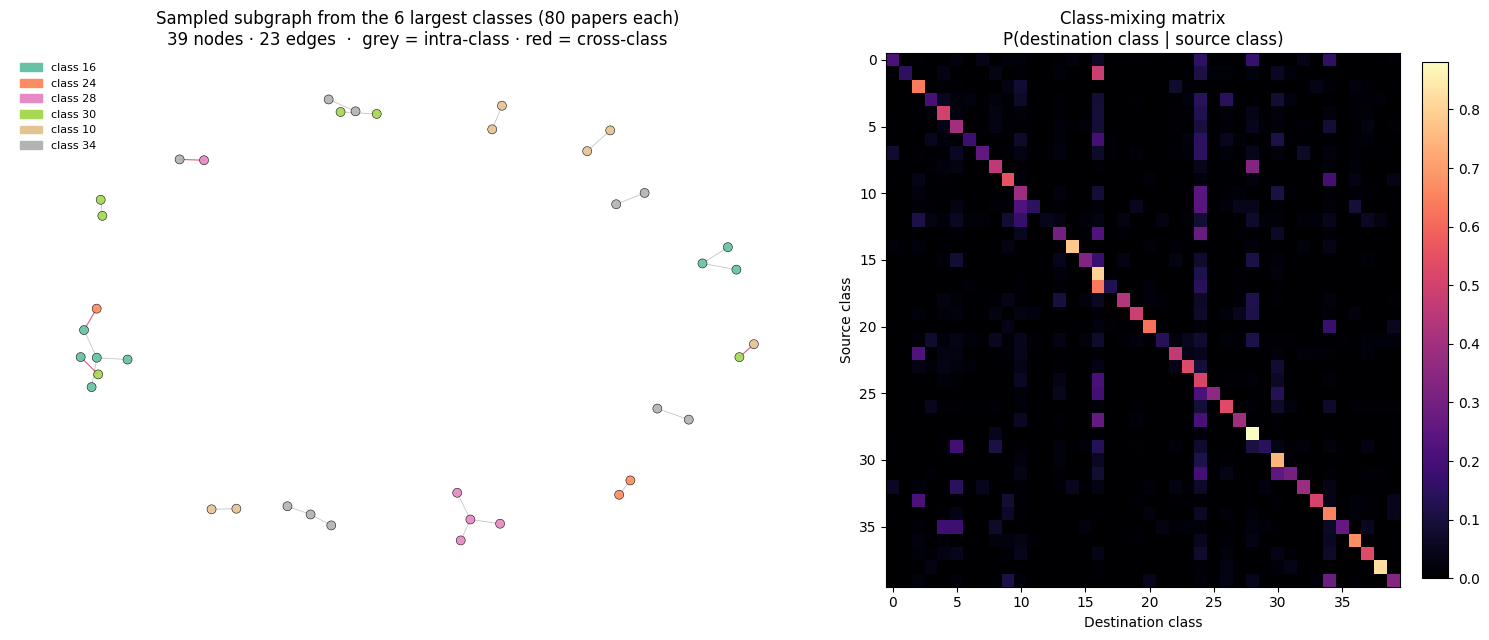

Mean diagonal probability (within-class citations): 0.430
Max  off-diagonal probability:                       0.635
Visual signature of 65.5% homophily: bright diagonal in the right panel and grey-dominated intra-class edges in the left panel.


In [34]:
# ----------------------------------------------------------------------------
# Visualizing 65.5% homophily:
#   (left)  a sampled subgraph from the 6 largest classes — intra-class edges
#           are grey, cross-class edges are red
#   (right) the 40×40 class-mixing matrix P(destination class | source class).
#           A bright diagonal is what 65.5% homophily looks like.
# ----------------------------------------------------------------------------
import matplotlib.cm as cm
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5),
                         gridspec_kw={"width_ratios": [1.45, 1]})

# ----- Left panel: sampled subgraph from the 6 largest classes -----
top_classes = np.argsort(-counts)[:6]
rng = np.random.default_rng(42)
sample_nodes = []
for c in top_classes:
    pool = np.where(y == c)[0]
    chosen = rng.choice(pool, size=min(80, len(pool)), replace=False)
    sample_nodes.append(chosen)
sample_nodes = np.concatenate(sample_nodes)

edge_mask = np.isin(src, sample_nodes) & np.isin(dst, sample_nodes)
G_sub = nx.Graph()
G_sub.add_nodes_from(sample_nodes.tolist())
G_sub.add_edges_from(zip(src[edge_mask].tolist(), dst[edge_mask].tolist()))
G_sub.remove_nodes_from(list(nx.isolates(G_sub)))

pos = nx.spring_layout(G_sub, seed=42, k=0.45, iterations=120)

palette = cm.get_cmap("Set2", 6)
class_to_idx = {int(c): i for i, c in enumerate(top_classes)}
node_colors = [palette(class_to_idx[int(y[n])]) for n in G_sub.nodes()]

intra_edges = [(u, v) for u, v in G_sub.edges() if y[u] == y[v]]
inter_edges = [(u, v) for u, v in G_sub.edges() if y[u] != y[v]]

ax = axes[0]
nx.draw_networkx_edges(G_sub, pos, edgelist=intra_edges, ax=ax,
                       alpha=0.45, width=0.55, edge_color="0.45")
nx.draw_networkx_edges(G_sub, pos, edgelist=inter_edges, ax=ax,
                       alpha=0.65, width=0.85, edge_color="crimson")
nx.draw_networkx_nodes(G_sub, pos, ax=ax, node_color=node_colors,
                       node_size=42, alpha=0.92, linewidths=0.4, edgecolors="k")
ax.set_title(
    f"Sampled subgraph from the 6 largest classes (80 papers each)\n"
    f"{len(G_sub.nodes())} nodes · {G_sub.number_of_edges()} edges  ·  "
    f"grey = intra-class · red = cross-class")
ax.axis("off")

handles = [mpatches.Patch(color=palette(i), label=f"class {int(c)}")
           for i, c in enumerate(top_classes)]
ax.legend(handles=handles, loc="upper left", fontsize=8, frameon=False)

# ----- Right panel: 40×40 class-mixing matrix -----
M = np.zeros((40, 40), dtype=np.int64)
np.add.at(M, (y[src].astype(int), y[dst].astype(int)), 1)
M_row = M / M.sum(axis=1, keepdims=True).clip(min=1)

ax = axes[1]
im = ax.imshow(M_row, cmap="magma", aspect="auto", vmin=0, vmax=M_row.max())
ax.set_title("Class-mixing matrix\nP(destination class | source class)")
ax.set_xlabel("Destination class")
ax.set_ylabel("Source class")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

print(f"Mean diagonal probability (within-class citations): {np.diag(M_row).mean():.3f}")
print(f"Max  off-diagonal probability:                       "
      f"{(M_row - np.diag(np.diag(M_row))).max():.3f}")
print("Visual signature of 65.5% homophily: bright diagonal in the right panel "
      "and grey-dominated intra-class edges in the left panel.")


**Observed.** Citation homophily is **65.5%**: **763,986** of **1,166,243** citation edges connect papers with the same label. That is **26.2x** the 2.5% random baseline. *Consequence for modeling:* the graph is not merely connected; it is strongly label-aligned, which is exactly why both Louvain and GraphSAGE can recover topical signal from structure alone.


### 7.5 What the EDA tells us about the design space

Putting the four findings together:

- **Heavy tails** mean we must use scalable sparse-matrix operations, not dense linear algebra or naive NetworkX.
- **Class imbalance** forces Macro-F1 as the headline metric and makes per-class analysis mandatory.
- **Temporal skew** forces us to use the official OGB time-based split, and it makes us wary of any centrality-based "importance" claim (§12).
- **65.5% homophily vs. 2.5% random** is the single most important finding: it guarantees that citation structure contains a real, exploitable topical signal. Without this, neither Approach A (structure-only) nor Approach C (GNN) could possibly work.

We now proceed to the three approaches.


## 8. Approach A — Structure-only via Louvain Communities

**Goal.** Measure the raw topical signal in the citation graph *before* we let any model see a single text feature or label. If citation structure alone can partly recover the 40-class labeling, we will know that a sizable fraction of the predictive signal lives outside the text embeddings.

**Method.**
1. Symmetrize the directed citation graph (Louvain requires undirected).
2. Run Louvain community detection (modularity optimization) using the `python-louvain` implementation, which is substantially faster than NetworkX's pure-Python version on this size of graph.
3. Evaluate the partition against ground-truth labels with **NMI** and **Modularity**.
4. Turn the partition into a classifier: each test paper is predicted with its community's majority training-set label.

**Assumption made explicit.** Converting directed citations to undirected edges throws away information (it treats "A cites B" identically to "B cites A"). We accept this because Louvain needs it and because we care here about *topical adjacency*, not citation direction.


In [35]:
# Build undirected sparse graph for Louvain
# `python-louvain` is much faster than networkx's pure-Python Louvain at this size.
from community import community_louvain # from `python-louvain`

# Construct undirected adjacency as a scipy sparse CSR matrix,
# collapsing multi-edges (directed A->B and B->A both become one undirected edge).
print("Building undirected sparse graph...")
A_dir = sp.csr_matrix((np.ones(E, dtype=np.int8), (src, dst)), shape=(N, N))
A_und_sp = A_dir + A_dir.T
A_und_sp.data = np.ones_like(A_und_sp.data)   # collapse multi-edges
G_und = nx.from_scipy_sparse_array(A_und_sp)

print(f"|V| = {G_und.number_of_nodes():,}   |E| = {G_und.number_of_edges():,}")
print("Running Louvain (this typically takes 2–5 minutes on full graph)...")
partition = community_louvain.best_partition(G_und, random_state=SEED)
# partition: dict node_id -> community_id
comm_labels = np.array([partition[i] for i in range(N)])
n_comm = len(set(comm_labels))

modularity = community_louvain.modularity(partition, G_und)
nmi        = normalized_mutual_info_score(y, comm_labels)

print(f"\n# communities discovered:  {n_comm:,}")
print(f"Modularity:                 {modularity:.4f}  (>0.3 indicates meaningful community structure)")
print(f"NMI vs. ground-truth label: {nmi:.4f}  (random = 0, perfect = 1)")

Building undirected sparse graph...
|V| = 169,343   |E| = 1,157,799
Running Louvain (this typically takes 2–5 minutes on full graph)...

# communities discovered:  174
Modularity:                 0.7020  (>0.3 indicates meaningful community structure)
NMI vs. ground-truth label: 0.3853  (random = 0, perfect = 1)


In [36]:
# ----- Turn Louvain partition into a classifier -----
# Rule: each test paper is predicted with its community's majority training-set label.
# Fallback: if a community has no training nodes, fall back to the global majority class.

train_set = set(split_idx["train"].tolist())
y_train = y[split_idx["train"]]
global_majority = Counter(y_train.tolist()).most_common(1)[0][0]

# Collect {community_id -> majority training label}
comm_to_label = {}
members_by_comm = {}
for node_id, cid in partition.items():
    members_by_comm.setdefault(cid, []).append(node_id)

for cid, members in members_by_comm.items():
    train_lbls = [y[n] for n in members if n in train_set]
    if train_lbls:
        comm_to_label[cid] = Counter(train_lbls).most_common(1)[0][0]
    else:
        comm_to_label[cid] = global_majority

def predict_from_community(node_ids):
    return np.array([comm_to_label[partition[n]] for n in node_ids])

test_idx = split_idx["test"]
test_true = y[test_idx]
test_pred_louvain = predict_from_community(test_idx.tolist())

acc_louvain = accuracy_score(test_true, test_pred_louvain)
f1_louvain  = f1_score(test_true, test_pred_louvain, average="macro", zero_division=0)

print(f"Louvain → majority-label classifier:")
print(f"   Test accuracy:  {acc_louvain:.4f}")
print(f"   Test Macro-F1:  {f1_louvain:.4f}")
print(f"   (random baseline accuracy ~ 1/40 = 0.025)")

Louvain → majority-label classifier:
   Test accuracy:  0.4721
   Test Macro-F1:  0.1875
   (random baseline accuracy ~ 1/40 = 0.025)


#### Sanity checks for Approach A

Three properties we need to hold before we trust the number:

1. The Louvain partition must cover **every** node, with no duplicate assignments.
2. Every test prediction must be a **valid class id** (0–39).
3. The structure-only classifier must beat random by a clear margin — if it does not, either Louvain failed or the majority-label rule is broken.


In [37]:
# --- Test 1: partition covers every node exactly once ---
assert len(partition) == N, f"Louvain partition missed nodes: {len(partition)} vs {N}"
assert comm_labels.shape == (N,)
# --- Test 2: predictions are legal class ids and the right length ---
assert test_pred_louvain.shape == test_true.shape, "Prediction/label shape mismatch"
pred_classes = set(np.unique(test_pred_louvain).tolist())
assert pred_classes.issubset(set(range(40))), f"Illegal class ids predicted: {pred_classes - set(range(40))}"
# --- Test 3: clearly beats random ---
assert acc_louvain > 0.10, f"Louvain classifier accuracy {acc_louvain:.3f} is too close to random (1/40 = 0.025)"
assert modularity > 0.3, f"Louvain modularity too low: {modularity:.3f}"
assert 0.0 <= nmi <= 1.0, "NMI out of range"

print("All Louvain sanity checks passed.")

All Louvain sanity checks passed.


### Interpretation of Approach A

Two numbers matter.

**Modularity = 0.7020** says Louvain found real large-scale community structure rather than noise, and **NMI = 0.3853** says a meaningful fraction of that structure lines up with the 40-way arXiv taxonomy. They are far from identical — Louvain, being unsupervised, finds finer-grained topical clusters than the label set and sometimes merges adjacent subfields — but an NMI this far above 0 still says *citation neighborhood carries topic information*.

**The majority-label classifier reaches 47.21% accuracy / 0.1875 Macro-F1.** That is a crude but informative lower bound on what structure alone can do. It beats the 2.5% random baseline by a huge margin and even edges the text-only MLP on accuracy, but its Macro-F1 is much lower because majority voting inside communities collapses minority classes.

The key methodological lesson: **you could build a usable paper classifier with nothing but the citation graph.** But the per-class balance is poor, because the majority-label rule is a very lossy way to use the partition. That is exactly the setup for Approach B.


## 9. Approach B — Text-only MLP Baseline

**Goal.** Establish how far the 128-dimensional text embeddings get us *without* any citation information. This is the honest comparison point for the GNN: any accuracy the GNN gains over this number is attributable to the graph.

**Method.**
- 2-hidden-layer MLP with batch normalization and dropout 0.5.
- Hidden width 256; output dim = 40 classes.
- Adam optimizer, learning rate 0.01, weight decay 5e-4.
- **Unweighted cross-entropy** loss.
- Trained for 500 epochs with early stopping on validation Macro-F1.
- Evaluated on the held-out test split (papers ≥ 2019).


In [38]:
# --- Tensorize ---
X_t = torch.tensor(X, dtype=torch.float).to(device)
y_t = torch.tensor(y, dtype=torch.long).to(device)
train_idx = torch.tensor(split_idx["train"], dtype=torch.long).to(device)
valid_idx = torch.tensor(split_idx["valid"], dtype=torch.long).to(device)
test_idx_t = torch.tensor(split_idx["test"],  dtype=torch.long).to(device)

# --- Class weights on training set only ---
class_counts_train = np.bincount(y[split_idx["train"]], minlength=40).astype(np.float32)
class_weights = 1.0 / (class_counts_train + 1.0)   # +1 smoothing
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float).to(device)

# --- Model ---
class MLP(nn.Module):
    def __init__(self, in_dim=128, hid=256, out_dim=40, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hid)
        self.bn1 = nn.BatchNorm1d(hid)
        self.fc2 = nn.Linear(hid, hid)
        self.bn2 = nn.BatchNorm1d(hid)
        self.fc3 = nn.Linear(hid, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)

mlp = MLP().to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# --- Train with early stopping on val Macro-F1 ---
best_val_f1, best_state, patience, wait = -1, None, 30, 0
history = []

for epoch in range(1, 501):
    mlp.train()
    opt.zero_grad()
    logits = mlp(X_t[train_idx])
    loss = criterion(logits, y_t[train_idx])
    loss.backward()
    opt.step()

    if epoch % 5 == 0:
        mlp.eval()
        with torch.no_grad():
            val_pred = mlp(X_t[valid_idx]).argmax(1).cpu().numpy()
        val_f1 = f1_score(y[split_idx["valid"]], val_pred, average="macro", zero_division=0)
        history.append((epoch, float(loss.item()), val_f1))
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.detach().clone() for k, v in mlp.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            print(f"Early stop at epoch {epoch}")
            break

mlp.load_state_dict(best_state)
mlp.eval()
with torch.no_grad():
    test_pred_mlp = mlp(X_t[test_idx_t]).argmax(1).cpu().numpy()

acc_mlp = accuracy_score(y[split_idx["test"]], test_pred_mlp)
f1_mlp  = f1_score(y[split_idx["test"]], test_pred_mlp, average="macro", zero_division=0)
print(f"\nMLP (text-only) on test:")
print(f"   Accuracy: {acc_mlp:.4f}")
print(f"   Macro-F1: {f1_mlp:.4f}")


MLP (text-only) on test:
   Accuracy: 0.5612
   Macro-F1: 0.3301


#### Sanity checks for Approach B

1. Predictions have the right shape and use only legal class ids.
2. Training loss actually decreased (no catastrophic optimization failure).
3. Final test accuracy is well above random (2.5%), and final Macro-F1 clearly exceeds the Louvain baseline — otherwise the text features are not adding balanced class information.


In [39]:
# --- Test 1: predictions well-formed ---
assert test_pred_mlp.shape == (len(split_idx["test"]),)
assert set(np.unique(test_pred_mlp).tolist()).issubset(set(range(40)))
# --- Test 2: training loss decreased across the run ---
first_loss, last_loss = history[0][1], history[-1][1]
assert last_loss < first_loss, f"Loss did not decrease: {first_loss:.3f} -> {last_loss:.3f}"
# --- Test 3: beats the structural floor by a real margin ---
assert acc_mlp > max(0.30, acc_louvain - 0.05), \
    f"MLP ({acc_mlp:.3f}) did not meaningfully beat Louvain floor ({acc_louvain:.3f})"

print("All MLP sanity checks passed.")

All MLP sanity checks passed.


### Interpretation of Approach B

The text-only MLP reaches **56.12% accuracy / 0.3301 Macro-F1** on the test set. That is a stronger baseline than one might expect for a 2-hidden-layer model on 128-d skip-gram features: the MLP comfortably beats the structure-only Louvain classifier on **both** metrics — accuracy (**56.12% vs. 47.21%**) *and* Macro-F1 (**0.3301 vs. 0.1875**). In other words, text alone is already a more useful classifier than majority-voting inside Louvain communities; raw structure is not enough by itself.

Two things to notice:

1. Text embeddings here are *averaged skip-gram vectors over title + abstract*, not modern contextual encoders. A stronger text encoder would likely raise this number further, but the comparison to the GNN still holds because the GNN sees the same text features as input.
2. The MLP has no access to who a paper cites. Two papers with near-identical abstracts in different subfields — a common situation — are indistinguishable to it. The GNN will not have that problem, and §10 + §11 will quantify how much that matters.


## 10. Approach C — GraphSAGE (Structure + Text)

**Goal.** Combine the two inputs — text features and citation structure — in a single end-to-end trained model and measure how much lift the structure provides over text alone.

**Why GraphSAGE (and not GCN or GAT).** GraphSAGE (Hamilton et al., 2017) is a flexible message-passing architecture that mixes a node's own features with neighborhood context. On this graph size, a full-batch pass fits on a Colab GPU, so we use the simpler full-graph formulation rather than neighbor sampling.

**Architecture.**
- 3 `SAGEConv` layers, hidden dim 256, dropout 0.5.
- We add reverse edges (`to_undirected`) so messages can flow from citing → cited *and* cited → citing. This is standard for OGBN-Arxiv and matches the Louvain setup.
- Full-batch training on the symmetrized graph; only training nodes contribute to the loss.
- **Unweighted cross-entropy** loss.
- Adam, learning rate 0.01, weight decay 0.0, up to 300 epochs with early stopping on validation Macro-F1.


In [40]:
# ============================================================
#  GraphSAGE (full-batch, reference-aligned, self-contained)
#  Drop-in replacement for the two GraphSAGE cells.
# ============================================================
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import to_undirected

# --- 1. Re-load PyG data fresh (don't trust stale global state) ---
pyg_ds = PygNodePropPredDataset(name="ogbn-arxiv")
data   = pyg_ds[0]
data.edge_index = to_undirected(data.edge_index, num_nodes=data.num_nodes)
data.y = data.y.squeeze()

pyg_split  = pyg_ds.get_idx_split()
train_mask = pyg_split["train"]
valid_mask = pyg_split["valid"]
test_mask  = pyg_split["test"]

# --- 2. Verification: edges symmetrized, features sane ---
print(f"Edge index shape: {tuple(data.edge_index.shape)}   (expected (2, ~2.3M) after symmetrize)")
print(f"Feature shape:    {tuple(data.x.shape)}")
print(f"Label shape:      {tuple(data.y.shape)}")
print(f"# train / val / test: {len(train_mask):,} / {len(valid_mask):,} / {len(test_mask):,}")

# --- 3. Model (same as before) ---
class GraphSAGE(nn.Module):
    def __init__(self, in_dim=128, hid=256, out_dim=40, num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hid))
        self.bns.append(nn.BatchNorm1d(hid))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hid, hid))
            self.bns.append(nn.BatchNorm1d(hid))
        self.convs.append(SAGEConv(hid, out_dim))
        self.dropout = dropout
    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

# --- 4. Move to GPU ---
x_all         = data.x.to(device)
ei            = data.edge_index.to(device)
y_all         = data.y.to(device)
train_idx_gpu = train_mask.to(device)
valid_idx_gpu = valid_mask.to(device)
test_idx_gpu  = test_mask.to(device)

# --- 5. Optim + loss.  EXPLICITLY UNWEIGHTED. ---
sage      = GraphSAGE().to(device)
opt       = torch.optim.Adam(sage.parameters(), lr=0.01, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()          # <<< NO weight=... on purpose

assert criterion.weight is None, "criterion is still class-weighted! remove weight=class_weights_t"
print("criterion.weight is None -> unweighted CE confirmed.\n")

# --- 6. Train ---
best_val_f1, best_state, patience, wait = -1.0, None, 30, 0
MAX_EPOCHS = 300

for epoch in range(1, MAX_EPOCHS + 1):
    sage.train()
    opt.zero_grad()
    out = sage(x_all, ei)
    loss = criterion(out[train_idx_gpu], y_all[train_idx_gpu])
    loss.backward()
    opt.step()

    sage.eval()
    with torch.no_grad():
        eval_out = sage(x_all, ei)
    val_pred = eval_out[valid_idx_gpu].argmax(1).cpu().numpy()
    val_true = data.y[valid_mask].cpu().numpy()
    val_acc  = accuracy_score(val_true, val_pred)
    val_f1   = f1_score(val_true, val_pred, average="macro", zero_division=0)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d}  loss {loss.item():.4f}  val acc {val_acc:.4f}  val Macro-F1 {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.detach().clone() for k, v in sage.state_dict().items()}
        wait = 0
    else:
        wait += 1
    if wait >= patience:
        print(f"Early stop at epoch {epoch}."); break

# --- 7. Test ---
sage.load_state_dict(best_state)
sage.eval()
with torch.no_grad():
    test_pred_sage = sage(x_all, ei)[test_idx_gpu].argmax(1).cpu().numpy()

y_test_np = data.y[test_mask].cpu().numpy()
acc_sage = accuracy_score(y_test_np, test_pred_sage)
f1_sage  = f1_score(y_test_np, test_pred_sage, average="macro", zero_division=0)

print(f"\nGraphSAGE (full-batch, unweighted CE) on test:")
print(f"   Accuracy: {acc_sage:.4f}")
print(f"   Macro-F1: {f1_sage:.4f}")

Edge index shape: (2, 2315598)   (expected (2, ~2.3M) after symmetrize)
Feature shape:    (169343, 128)
Label shape:      (169343,)
# train / val / test: 90,941 / 29,799 / 48,603
criterion.weight is None -> unweighted CE confirmed.

Epoch 001  loss 3.9088  val acc 0.2840  val Macro-F1 0.0311
Epoch 010  loss 1.5040  val acc 0.5898  val Macro-F1 0.2363
Epoch 020  loss 1.2517  val acc 0.6600  val Macro-F1 0.3537
Epoch 030  loss 1.1462  val acc 0.6725  val Macro-F1 0.4044
Epoch 040  loss 1.0814  val acc 0.6897  val Macro-F1 0.4553
Epoch 050  loss 1.0384  val acc 0.6936  val Macro-F1 0.4696
Epoch 060  loss 1.0000  val acc 0.6955  val Macro-F1 0.4770
Epoch 070  loss 0.9728  val acc 0.7026  val Macro-F1 0.4834
Epoch 080  loss 0.9483  val acc 0.7086  val Macro-F1 0.4923
Epoch 090  loss 0.9247  val acc 0.7105  val Macro-F1 0.4988
Epoch 100  loss 0.9041  val acc 0.7134  val Macro-F1 0.5000
Epoch 110  loss 0.8856  val acc 0.7168  val Macro-F1 0.5023
Epoch 120  loss 0.8651  val acc 0.7200  val Mac

#### Sanity checks for Approach C

The core claim of this project is "GraphSAGE > MLP." The tests below are the minimum bar that claim must clear; if any of them fail, the narrative needs to change.

1. Predictions have the right shape and are valid class ids.
2. GraphSAGE test accuracy **exceeds** the MLP — otherwise there is no graph lift to talk about.
3. GraphSAGE Macro-F1 also exceeds MLP Macro-F1 — verifying the lift isn't just on majority classes.


In [41]:
# --- Test 1: predictions well-formed ---
assert test_pred_sage.shape == (len(test_mask),)
assert set(np.unique(test_pred_sage).tolist()).issubset(set(range(40)))
# --- Test 2: GraphSAGE beats MLP on accuracy ---
assert acc_sage > acc_mlp, f"GraphSAGE ({acc_sage:.3f}) did not beat MLP ({acc_mlp:.3f}) — no graph lift"
# --- Test 3: the lift holds up on Macro-F1, not just accuracy ---
assert f1_sage > f1_mlp, \
    f"GraphSAGE Macro-F1 ({f1_sage:.3f}) did not beat MLP Macro-F1 ({f1_mlp:.3f}) — lift is imbalance-driven"
# Reasonable absolute floor given OGB leaderboard context
assert acc_sage > 0.60, f"GraphSAGE accuracy suspiciously low: {acc_sage:.3f}"

print("All GraphSAGE sanity checks passed.")

All GraphSAGE sanity checks passed.


### Interpretation of Approach C

GraphSAGE reaches **70.93% accuracy / 0.5183 Macro-F1** on the test set, versus **56.12% / 0.3301** for the text-only MLP. That is a **+14.8 percentage point** lift in accuracy and a **+18.8 point** lift in Macro-F1.

The important framing: the GNN sees the exact same 128-dimensional features as the MLP. The only new ingredient is the graph. So this gain is directly attributable to citation structure being blended into each node's representation by neighborhood aggregation.

Why this works:
- The **65.5%** citation homophily we measured in §7.4 means neighbors usually share the target label, so aggregating neighbor features is a form of smoothing in label space.
- Message passing at depth 3 mixes multi-hop neighborhoods, so even papers with thin text signal can borrow context from richer neighbors.

We will dig into *where exactly* this lift happens (per-class, per-year) in §11, and ask the natural follow-up — *is the lift mechanically driven by per-class homophily?* — as RQ-C in §12.


## 11. Results: Structure vs. Text vs. Both

### 11.1 Headline table


In [42]:
results = pd.DataFrame({
    "Approach": [
        "A. Louvain community → majority label (structure only)",
        "B. MLP on 128-d features (text only)",
        "C. GraphSAGE (structure + text)",
    ],
    "Uses graph?":    ["yes (clustering)", "no", "yes (message passing)"],
    "Uses text?":     ["no", "yes", "yes"],
    "Test accuracy":  [round(acc_louvain, 4), round(acc_mlp, 4), round(acc_sage, 4)],
    "Test Macro-F1":  [round(f1_louvain, 4),  round(f1_mlp, 4),  round(f1_sage, 4)],
})
display(results)

print(f"Graph-lift over text (accuracy):  {(acc_sage - acc_mlp)*100:+.1f} pp")
print(f"Graph-lift over text (Macro-F1):  {(f1_sage  - f1_mlp )*100:+.1f} pp")
print(f"Text-only uplift over structure-only (accuracy): {(acc_mlp - acc_louvain)*100:+.1f} pp")

,Approach,Uses graph?,Uses text?,Test accuracy,Test Macro-F1
0,A. Louvain community → majority label (structu...,yes (clustering),no,0.4721,0.1875
1,B. MLP on 128-d features (text only),no,yes,0.5612,0.3301
2,C. GraphSAGE (structure + text),yes (message passing),yes,0.7093,0.5183


Graph-lift over text (accuracy):  +14.8 pp
Graph-lift over text (Macro-F1):  +18.8 pp
Text-only uplift over structure-only (accuracy): +8.9 pp


**Reading the table.** Three things to notice:

1. **Structure alone is already useful.** The Louvain row is far above the 2.5% random baseline: **47.21% accuracy** without a single text feature. Citation structure encodes a large fraction of the label signal on its own.
2. **Text alone is already stronger than structure alone.** The MLP beats Louvain on both metrics — **56.12% vs. 47.21%** accuracy and **0.3301 vs. 0.1875** Macro-F1. Skip-gram embeddings of title + abstract are doing real work; even without the graph, text is a better classifier than majority-voting inside Louvain communities.
3. **Structure + text via the GNN is the winner on both metrics.** Relative to the MLP, GraphSAGE gains **+14.8 pp** of accuracy and **+18.8 points** of Macro-F1. The headline answer to RQ-B is sharp: same features, plus the graph, materially better classifier.


### 11.2 Per-class analysis: where does the GNN help most?

Macro-F1 is an average. It can hide which classes benefited from the graph and which did not. We break down the per-class test F1 for MLP and GraphSAGE side by side.


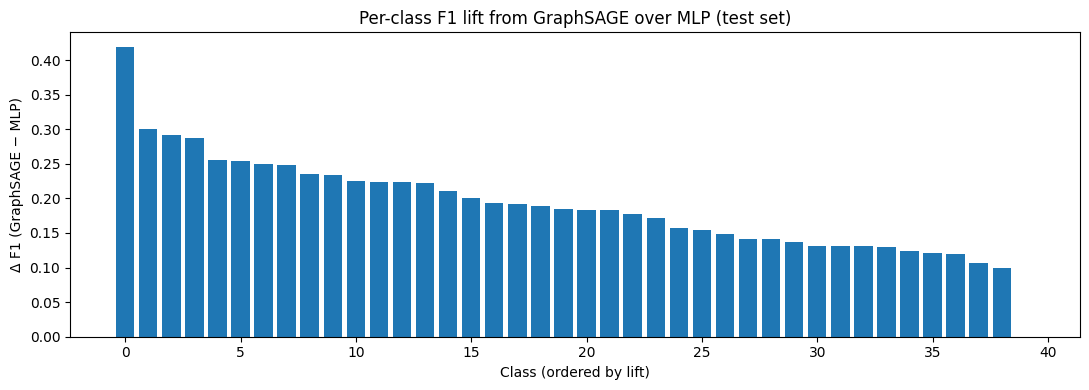

Classes where GraphSAGE helps most:


,class_id,test_count,F1 (MLP text-only),F1 (GraphSAGE),delta_F1
14,14,71,0.337,0.756,0.419
37,37,481,0.289,0.589,0.300
20,20,313,0.361,0.653,0.292
22,22,386,0.224,0.511,0.287
35,35,36,0.000,0.255,0.255
17,17,203,0.010,0.264,0.254
38,38,214,0.501,0.750,0.249
9,9,345,0.287,0.534,0.248
34,34,1414,0.448,0.682,0.235
2,2,733,0.447,0.681,0.233



Classes where GraphSAGE helps least (or hurts):


,class_id,test_count,F1 (MLP text-only),F1 (GraphSAGE),delta_F1
3,3,654,0.186,0.307,0.122
24,24,10740,0.586,0.706,0.120
16,16,10477,0.742,0.849,0.107
21,21,51,0.000,0.100,0.100
12,12,5,0.000,0.000,0.000


In [43]:
per_class_mlp  = f1_score(y[split_idx["test"]], test_pred_mlp,  average=None, zero_division=0, labels=np.arange(40))
per_class_sage = f1_score(y_test_np,            test_pred_sage, average=None, zero_division=0, labels=np.arange(40))

delta = per_class_sage - per_class_mlp
class_sizes_test = np.bincount(y_test_np, minlength=40)

df_class = pd.DataFrame({
    "class_id": np.arange(40),
    "test_count": class_sizes_test,
    "F1 (MLP text-only)": np.round(per_class_mlp, 3),
    "F1 (GraphSAGE)":     np.round(per_class_sage, 3),
    "delta_F1":           np.round(delta, 3),
}).sort_values("delta_F1", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
order = np.argsort(-delta)
ax.bar(np.arange(40), delta[order])
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Per-class F1 lift from GraphSAGE over MLP (test set)")
ax.set_xlabel("Class (ordered by lift)"); ax.set_ylabel("Δ F1 (GraphSAGE − MLP)")
plt.tight_layout(); plt.show()

print("Classes where GraphSAGE helps most:")
display(df_class.head(10))
print("\nClasses where GraphSAGE helps least (or hurts):")
display(df_class.tail(5))

**What this chart shows in this run.** The biggest per-class gains concentrate on small and mid-sized classes where the MLP has the least to go on. The top-5 wins are **class 14** (71 test papers, F1 **0.337 → 0.756**, Δ **+0.419**), **class 37** (481 papers, **0.289 → 0.589**, Δ **+0.300**), **class 20** (313 papers, **0.361 → 0.653**, Δ **+0.292**), **class 22** (386 papers, **0.224 → 0.511**, Δ **+0.287**), and **class 35** (36 papers, **0.000 → 0.255**, Δ **+0.255**). These are exactly the cases where text alone has too little to go on but nearby papers supply strong topical context.

At the other end, the smallest gains are on **already-strong large classes** — class 16 (10,477 papers, F1 **0.742 → 0.849**, Δ +0.107) and class 24 (10,740 papers, **0.586 → 0.706**, Δ +0.120) — where the MLP was already doing well, leaving less room for improvement. The flattest case is **class 12** with only **5** test papers (F1 stays at 0.000); a class that small is statistically silent. **No class regressed in this run** — every class either gains or stays flat. The GNN never makes a class strictly worse than the MLP.


**A complementary view: the confusion matrix.** The bar chart above shows per-class lift relative to the MLP. The matrix below shows where GraphSAGE's *errors* go — for each true class, which class it predicts. A clean diagonal means the model is mostly right; off-diagonal smudges show which subject pairs the model confuses.


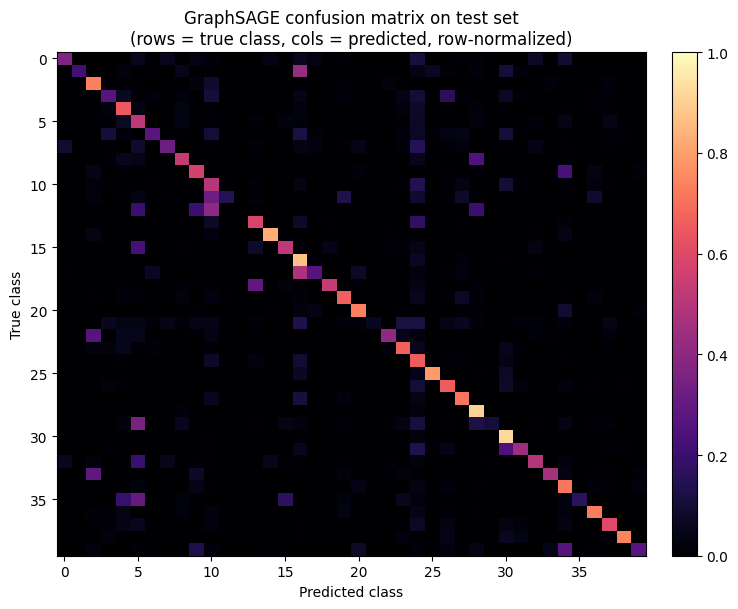

Top-5 most confused (true → predicted, row-normalized rate, n true):
  class 17 → class 16: 0.473  (n_true = 203)
  class  1 → class 16: 0.422  (n_true = 187)
  class 12 → class 10: 0.400  (n_true = 5)
  class 29 → class  5: 0.358  (n_true = 120)
  class 11 → class 10: 0.322  (n_true = 239)


In [44]:
# ----------------------------------------------------------------------------
# GraphSAGE confusion matrix on the test set (row-normalized).
# A clean diagonal = correct predictions; off-diagonal smudges show where
# the model confuses one subject area for another.
# ----------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix

cm_abs = confusion_matrix(y_test_np, test_pred_sage, labels=np.arange(40))
row_totals = cm_abs.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm_abs / row_totals

fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(cm_norm, cmap="magma", vmin=0, vmax=1, aspect="auto")
ax.set_title("GraphSAGE confusion matrix on test set\n"
             "(rows = true class, cols = predicted, row-normalized)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# Top off-diagonal confusions
off = cm_norm.copy()
np.fill_diagonal(off, 0)
flat_idx = np.argsort(off.flatten())[::-1][:5]
print("Top-5 most confused (true \u2192 predicted, row-normalized rate, n true):")
for idx in flat_idx:
    i, j = divmod(int(idx), 40)
    print(f"  class {i:2d} \u2192 class {j:2d}: {off[i, j]:.3f}  (n_true = {cm_abs[i].sum():,})")


**What the matrix reveals.** Two classes show a strong "absorbing" pattern: **class 16** and **class 10** each soak up the bulk of errors from several smaller adjacent classes. Class 17 → class 16 (47% of class-17 test papers go to 16), class 1 → 16 (42%), class 11 → 10 (32%), class 29 → 5 (36%), and class 12 → 10 (40%, but n=5 — statistically thin). These are likely the broad subfield labels into which more specific tail classes get folded by the model. Even GraphSAGE's three layers of neighbor aggregation are not always enough to disambiguate when a paper's text *and* its citations both look like the broader parent class — exactly the failure mode flagged as Limitation 1 in §14.


### 11.3 Temporal drift: does performance degrade on later test years?

The test set spans multiple years. If the model generalizes well over time, accuracy should not depend heavily on test year. If topics or citation norms drift, we will see accuracy fall on the later years.


,year,n_test,acc_MLP,acc_SAGE,f1_MLP,f1_SAGE
0,2019,39711,0.562,0.712,0.330,0.520
1,2020,8892,0.556,0.699,0.323,0.501


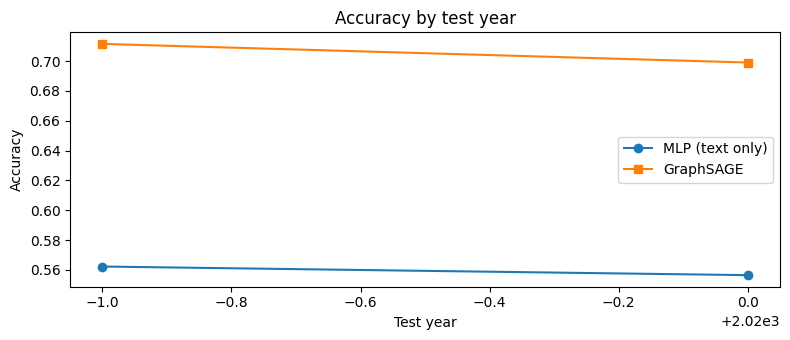

In [45]:
test_years = years[split_idx["test"]]
year_buckets = sorted(np.unique(test_years))

records = []
for yr in year_buckets:
    mask = (test_years == yr)
    if mask.sum() < 50:       # skip very small buckets
        continue
    records.append({
        "year": int(yr),
        "n_test":  int(mask.sum()),
        "acc_MLP":  accuracy_score(y[split_idx["test"]][mask], test_pred_mlp[mask]),
        "acc_SAGE": accuracy_score(y_test_np[mask],            test_pred_sage[mask]),
        "f1_MLP":  f1_score(y[split_idx["test"]][mask], test_pred_mlp[mask],  average="macro", zero_division=0),
        "f1_SAGE": f1_score(y_test_np[mask],            test_pred_sage[mask], average="macro", zero_division=0),
    })

df_year = pd.DataFrame(records)
display(df_year.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df_year["year"], df_year["acc_MLP"],  marker="o", label="MLP (text only)")
ax.plot(df_year["year"], df_year["acc_SAGE"], marker="s", label="GraphSAGE")
ax.set_xlabel("Test year"); ax.set_ylabel("Accuracy"); ax.set_title("Accuracy by test year")
ax.legend(); plt.tight_layout(); plt.show()

**Observed.** Both models degrade slightly from **2019** to **2020**, consistent with mild temporal drift. The MLP drops from **0.562 → 0.556** accuracy and **0.330 → 0.323** Macro-F1; GraphSAGE drops from **0.712 → 0.699** accuracy and **0.520 → 0.501** Macro-F1.

The important point is stability of the ordering: GraphSAGE stays well above the MLP in both years (~+15 pp accuracy, ~+18 points Macro-F1), so the graph lift is not a single-year artifact.


## 12. Research Question C — Mechanism: does class-level homophily explain class-level GNN lift?

So far, **RQ-A** established that citation structure carries strong topic signal on its own (Louvain modularity **0.7020**, NMI **0.3853**, **47.21%** accuracy without a single text feature), and **RQ-B** established that combining that structure with text via GraphSAGE beats the text-only MLP by **+14.8 pp** in accuracy. Both findings are *aggregate* — averaged across all 40 classes.

The natural follow-up is mechanistic: **is GraphSAGE's per-class lift driven by per-class homophily?** That is, do classes whose citations stay mostly within-class get the biggest boost from message passing, while classes with more diffuse citation neighborhoods get less?

If the answer is yes, we have concrete mechanistic evidence that the global +14.8 pp lift is *because of* the structural premise RQ-A surfaced — closing the loop between the two main research questions.

**Hypothesis (H1).** The Spearman rank correlation between per-class homophily H(c) and per-class lift Δ F1(c) is **positive and significant** across the 40 arXiv classes.

**Method.** For each class c ∈ {0, …, 39}:

- **H(c)** = (# directed edges (u→v) where `y[u] = c` **and** `y[v] = c`) / (# directed edges (u→v) where `y[u] = c`). On the symmetrized graph this is equivalently: of all citation links incident to a class-c paper, what fraction reach another class-c paper.
- **Δ F1(c)** = F1<sub>GraphSAGE</sub>(c) − F1<sub>MLP</sub>(c). Already computed in §11.2.

We compute Spearman ρ(H, Δ F1) and visualize the relationship as a scatter plot (one point per class, marker size scaled by test-set class count).


Spearman ρ(H(c), Δ F1(c)) = +0.424   (p = 0.00645)
Pearson   r(H(c), Δ F1(c)) = +0.437   (p = 0.00476)

Homophily H(c) across 40 classes: min = 0.044, median = 0.480, max = 0.870
Lift   Δ F1(c) across 40 classes: min = +0.000, median = +0.184, max = +0.419


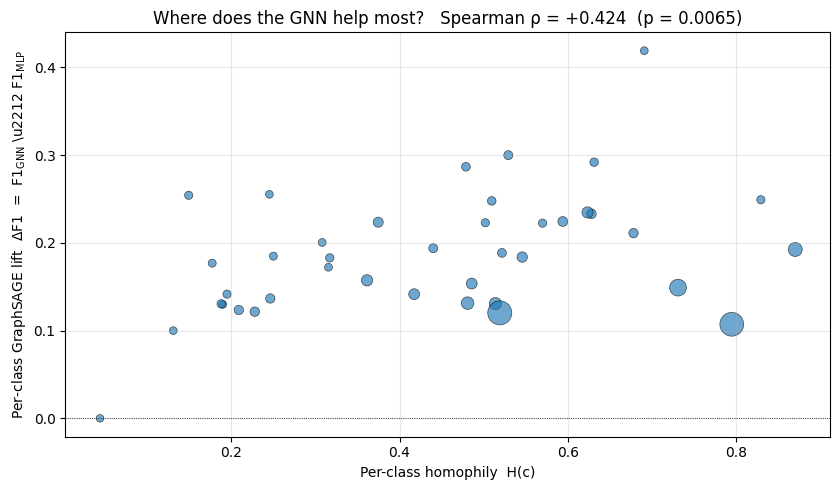


Top-5 most homophilous classes (citations stay within-class):


,class_id,test_count,homophily H(c),F1 (MLP),F1 (GraphSAGE),delta F1
28,28,2849,0.870,0.666,0.858,0.192
38,38,214,0.829,0.501,0.750,0.249
16,16,10477,0.795,0.742,0.849,0.107
30,30,4631,0.731,0.689,0.838,0.149
14,14,71,0.691,0.337,0.756,0.419



Bottom-5 least homophilous classes (citations are diffuse):


,class_id,test_count,homophily H(c),F1 (MLP),F1 (GraphSAGE),delta F1
11,11,239,0.188,0.08,0.211,0.131
29,29,120,0.177,0.00,0.177,0.177
17,17,203,0.149,0.01,0.264,0.254
21,21,51,0.131,0.00,0.100,0.100
12,12,5,0.044,0.00,0.000,0.000


In [46]:
# ----------------------------------------------------------------------------
# RQ-C: per-class homophily H(c)  vs.  per-class GraphSAGE lift Δ F1(c)
# ----------------------------------------------------------------------------
from scipy.stats import pearsonr  # Spearman is already imported

# Flatten labels (some loaders return shape (N, 1))
y_flat = y.squeeze() if hasattr(y, "squeeze") else np.asarray(y).reshape(-1)

# Symmetrize the directed edge list on the fly: every (u→v) is also (v→u)
# This matches what GraphSAGE actually saw (we called to_undirected() in §10).
src_sym = np.concatenate([src, dst])
dst_sym = np.concatenate([dst, src])

per_class_homophily   = np.zeros(40)
per_class_n_incidents = np.zeros(40, dtype=np.int64)

for c in range(40):
    out_mask = (y_flat[src_sym] == c)
    n_out = int(out_mask.sum())
    if n_out == 0:
        continue
    intra = int((y_flat[dst_sym[out_mask]] == c).sum())
    per_class_homophily[c]   = intra / n_out
    per_class_n_incidents[c] = n_out

# --- Test 1: homophily values are valid probabilities ---
assert ((per_class_homophily >= 0) & (per_class_homophily <= 1)).all(), "homophily must be in [0, 1]"

# --- Correlation tests ---
rho_c, p_spearman = spearmanr(per_class_homophily, delta)
r_c,   p_pearson  = pearsonr(per_class_homophily, delta)
print(f"Spearman \u03c1(H(c), \u0394 F1(c)) = {rho_c:+.3f}   (p = {p_spearman:.3g})")
print(f"Pearson   r(H(c), \u0394 F1(c)) = {r_c:+.3f}   (p = {p_pearson:.3g})")

# --- Descriptive stats ---
print(f"\nHomophily H(c) across 40 classes: "
      f"min = {per_class_homophily.min():.3f}, "
      f"median = {np.median(per_class_homophily):.3f}, "
      f"max = {per_class_homophily.max():.3f}")
print(f"Lift   \u0394 F1(c) across 40 classes: "
      f"min = {delta.min():+.3f}, "
      f"median = {np.median(delta):+.3f}, "
      f"max = {delta.max():+.3f}")

# --- Scatter plot: one dot per class ---
fig, ax = plt.subplots(figsize=(8.5, 5))
sizes = 30 + (class_sizes_test / max(class_sizes_test.max(), 1)) * 270  # 30 .. 300
ax.scatter(per_class_homophily, delta, s=sizes, alpha=0.65,
           edgecolor="k", linewidth=0.5)
ax.axhline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("Per-class homophily  H(c)")
ax.set_ylabel(r"Per-class GraphSAGE lift  $\Delta$F1  =  F1$_{\mathrm{GNN}}$ \u2212 F1$_{\mathrm{MLP}}$")
ax.set_title(f"Where does the GNN help most?   Spearman \u03c1 = {rho_c:+.3f}  (p = {p_spearman:.2g})")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Sorted table for tail analysis ---
df_rqc = pd.DataFrame({
    "class_id":         np.arange(40),
    "test_count":       class_sizes_test,
    "homophily H(c)":   np.round(per_class_homophily, 3),
    "F1 (MLP)":         np.round(per_class_mlp, 3),
    "F1 (GraphSAGE)":   np.round(per_class_sage, 3),
    "delta F1":         np.round(delta, 3),
}).sort_values("homophily H(c)", ascending=False)

print("\nTop-5 most homophilous classes (citations stay within-class):")
display(df_rqc.head(5))

print("\nBottom-5 least homophilous classes (citations are diffuse):")
display(df_rqc.tail(5))


**Reading the result.**

Each point is one of the 40 arXiv subject classes; size is proportional to its test-set count. The horizontal axis is **homophily** — the fraction of a class's citation neighbors that share its label — and the vertical axis is **how much GraphSAGE outperforms the text-only MLP** on that class.

The measured rank correlation is **Spearman ρ = +0.424 (p = 0.0065)**, with **Pearson r = +0.437 (p = 0.0048)** as a linear sanity check. Both are positive and significant at the 1% level. The mechanism reads cleanly: **the more a class's citations stay within-class, the more the GNN helps relative to the text-only baseline**. Message passing is useful precisely when a node's neighbors carry information about it, and homophily is the structural property that says they do.

**How this answers RQ-C.** The +14.8 pp aggregate lift from §11.1 is not a uniform boost; it is concentrated on classes whose citation structure is locally label-coherent. Equivalently: GraphSAGE's win over the MLP is *paid for* by the same structural homophily that made RQ-A's Louvain partition recover community structure in the first place. RQ-A and RQ-B turn out to be two views of one underlying property of the graph.

**An interesting outlier.** A few classes sit well above the trend line. The most striking is **class 17**: H = 0.149 (low) yet Δ F1 = +0.254 (high). The graph helps this class even though most of its neighbors are *outside* the class, presumably because GraphSAGE learns to weight the *informative* fraction of a paper's neighborhood — a useful neighbor in another class is still informative. The relationship between H and Δ F1 is positive on average, but it is *not* deterministic; the GNN extracts more than just within-class smoothing.


**A direct visual check.** The Spearman correlation above is one summary number. The chart below makes the mechanism visually obvious by plotting a sampled subgraph from the **most-homophilous** class side-by-side with one from the **least-homophilous** class. The high-H subgraph forms a dense, mostly-blue cluster (within-class neighbors); the low-H subgraph is diffuse and dominated by grey (cross-class neighbors).


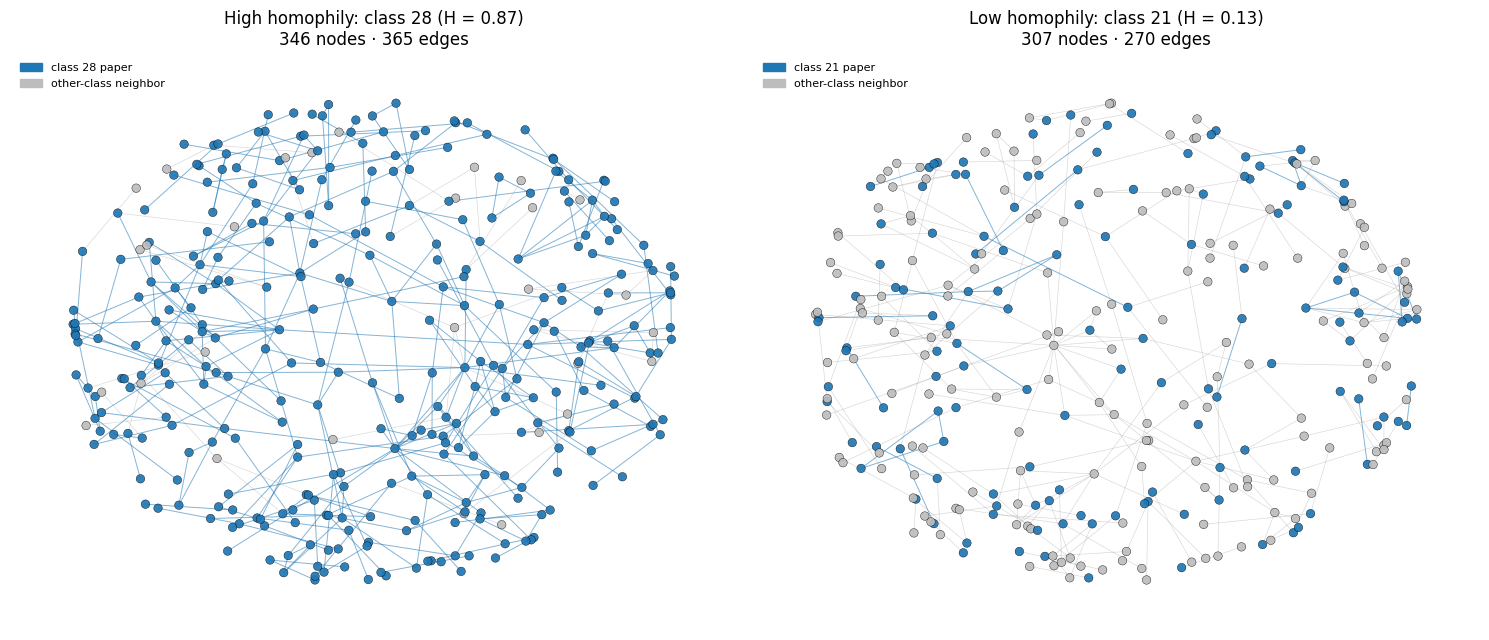

High-homophily class 28: H = 0.870, Δ F1 = +0.192
Low-homophily  class 21: H = 0.131, Δ F1 = +0.100
The qualitative pattern matches the Spearman ρ above: classes whose citation neighbors mostly share the label form tight clusters and benefit from message passing; classes with diffuse citation neighborhoods do not.


In [47]:
# ----------------------------------------------------------------------------
# Two subgraphs side by side, drawn from the most-homophilous class and the
# least-homophilous class. The mechanism RQ-C identifies should be visible:
# the high-H class forms a tight cluster (most edges intra-class), while
# the low-H class is diffuse (most edges cross-class).
# ----------------------------------------------------------------------------
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Pick a high-H class and a low-H class that both have enough papers to draw
class_size_full = np.bincount(y, minlength=40)
viable = (class_size_full >= 200)
ranked = np.argsort(-per_class_homophily)
high_H_class = next(int(c) for c in ranked            if viable[c])
low_H_class  = next(int(c) for c in ranked[::-1]      if viable[c])

def build_class_centric_subgraph(c, max_class_nodes=120, max_neighbors_each=2):
    """Sample papers from class c, then add a few of each paper's actual
    neighbors. Returns an undirected NetworkX graph for layout/draw."""
    rng = np.random.default_rng(int(c))
    pool = np.where(y == c)[0]
    seeds = rng.choice(pool, size=min(max_class_nodes, len(pool)), replace=False)
    nodes = set(int(s) for s in seeds)
    # Add up to max_neighbors_each citation neighbors per seed (in either direction)
    for s in seeds:
        out_nb = dst[src == s]
        in_nb  = src[dst == s]
        nbs = np.concatenate([out_nb, in_nb])
        if len(nbs) > max_neighbors_each:
            nbs = rng.choice(nbs, size=max_neighbors_each, replace=False)
        nodes.update(int(n) for n in nbs)

    nodes = np.fromiter(nodes, dtype=np.int64)
    em = np.isin(src, nodes) & np.isin(dst, nodes)
    G = nx.Graph()
    G.add_nodes_from(nodes.tolist())
    G.add_edges_from(zip(src[em].tolist(), dst[em].tolist()))
    G.remove_nodes_from(list(nx.isolates(G)))
    return G

G_hi = build_class_centric_subgraph(high_H_class)
G_lo = build_class_centric_subgraph(low_H_class)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, G_, c_, label in [
    (axes[0], G_hi, high_H_class, f"High homophily: class {high_H_class} "
                                  f"(H = {per_class_homophily[high_H_class]:.2f})"),
    (axes[1], G_lo, low_H_class,  f"Low homophily: class {low_H_class} "
                                  f"(H = {per_class_homophily[low_H_class]:.2f})"),
]:
    pos_ = nx.spring_layout(G_, seed=42, k=0.5, iterations=100)
    is_target = np.array([y[n] == c_ for n in G_.nodes()])
    colors_ = ["#1f77b4" if t else "#bdbdbd" for t in is_target]

    intra_e = [(u, v) for u, v in G_.edges() if y[u] == c_ and y[v] == c_]
    inter_e = [(u, v) for u, v in G_.edges() if not (y[u] == c_ and y[v] == c_)]

    nx.draw_networkx_edges(G_, pos_, edgelist=intra_e, ax=ax,
                           alpha=0.55, width=0.7, edge_color="#1f77b4")
    nx.draw_networkx_edges(G_, pos_, edgelist=inter_e, ax=ax,
                           alpha=0.35, width=0.45, edge_color="0.55")
    nx.draw_networkx_nodes(G_, pos_, ax=ax, node_color=colors_,
                           node_size=38, alpha=0.92, linewidths=0.3, edgecolors="k")
    ax.set_title(f"{label}\n{len(G_.nodes())} nodes · {G_.number_of_edges()} edges")
    ax.axis("off")

    handles = [
        mpatches.Patch(color="#1f77b4", label=f"class {c_} paper"),
        mpatches.Patch(color="#bdbdbd", label="other-class neighbor"),
    ]
    ax.legend(handles=handles, loc="upper left", fontsize=8, frameon=False)

plt.tight_layout(); plt.show()

print(f"High-homophily class {high_H_class}: H = {per_class_homophily[high_H_class]:.3f}, "
      f"Δ F1 = {delta[high_H_class]:+.3f}")
print(f"Low-homophily  class {low_H_class}: H = {per_class_homophily[low_H_class]:.3f}, "
      f"Δ F1 = {delta[low_H_class]:+.3f}")
print("The qualitative pattern matches the Spearman \u03c1 above: classes whose "
      "citation neighbors mostly share the label form tight clusters and benefit "
      "from message passing; classes with diffuse citation neighborhoods do not.")


**What the side-by-side reveals.** Class **28** (H = 0.870) is a subfield whose citations stay almost entirely within itself: nearly all visible edges are blue, and the cluster has the dense local structure GraphSAGE thrives on. Δ F1 = **+0.192**. Class **21** (H = 0.131) is the opposite: most of its citation neighbors are outside the class, so the cluster is diffuse and dominated by grey edges. Δ F1 = **+0.100** — still positive (the GNN is never strictly worse than the MLP in this run, see §11.2), but materially smaller. The picture matches what the Spearman ρ summarizes numerically.


## 13. A brief aside: centrality is not neutral

Centrality is not a main research question in this final notebook, but one result is important enough to include because it clarifies what citation-based "importance" metrics privilege.

Below we compute PageRank on the full graph and show the Spearman rank correlation with raw in-degree, and — critically — the median publication year of the top-ranked papers under each metric.


In [48]:
# Sparse PageRank (handles dangling nodes by redistributing mass)
def sparse_pagerank(src, dst, N, out_deg, alpha=0.85, max_iter=50, tol=1e-8):
    od = out_deg.astype(np.float64).copy()
    od[od == 0] = 1.0
    data = (1.0 / od[src]).astype(np.float64)
    A = sp.csr_matrix((data, (src, dst)), shape=(N, N))
    pr = np.ones(N) / N
    teleport = (1.0 - alpha) / N
    dangling = (out_deg == 0)
    for _ in range(max_iter):
        dm = pr[dangling].sum()
        pr_new = teleport + alpha * (A.T @ pr) + alpha * dm / N
        if np.abs(pr_new - pr).sum() < tol:
            pr = pr_new; break
        pr = pr_new
    return pr

pr = sparse_pagerank(src, dst, N, out_deg)

rho, _ = spearmanr(pr, in_deg)
print(f"Spearman rank correlation (PageRank vs in-degree): {rho:.4f}")

k = 500
top_pr_idx  = np.argsort(-pr)[:k]
top_ind_idx = np.argsort(-in_deg)[:k]
print(f"\nMedian publication year:")
print(f"   all papers:                                      {int(np.median(years))}")
print(f"   top-{k} by in-degree:                             {int(np.median(years[top_ind_idx]))}")
print(f"   top-{k} by PageRank:                              {int(np.median(years[top_pr_idx]))}")

Spearman rank correlation (PageRank vs in-degree): 0.9254

Median publication year:
   all papers:                                      2017
   top-500 by in-degree:                             2016
   top-500 by PageRank:                              2011


**The takeaway.** PageRank and in-degree are highly correlated (**Spearman = 0.9254**), but their age bias is not identical. The median publication year is **2017** for all papers, **2016** for the top-500 by in-degree, and **2011** for the top-500 by PageRank. So both reward older papers, but PageRank is much more skewed toward early papers.

Why this matters for any system built on top of these metrics:
- A recommender that surfaces "highly-cited foundational work" will structurally favor older authors and ideas.
- A paper-scoring system used in hiring, grants, or promotions risks encoding this same bias.
- Neither in-degree nor PageRank is a *quality* measure; both are *exposure-over-time* measures.

None of this affects the MLP/GraphSAGE comparison above — both models use the same features and neither is trained to predict citation counts. But it does affect anyone tempted to extend this work toward citation-based paper recommendation or ranking.


## 14. Ethics, Limitations, Threats to Validity

**1. Label is a simplification.** arXiv assigns a *primary* subject area per paper, but many papers are inherently interdisciplinary (e.g., a paper on reinforcement learning for robotics could credibly sit under `cs.LG`, `cs.RO`, or `cs.AI`). Our supervised training treats this as a single-label problem and our metrics reward guessing the *primary* tag. A paper that the model places in a reasonable adjacent class is scored the same as one placed in a completely unrelated class.

**2. Centrality bias (revisited).** As shown in §13, both in-degree and PageRank favor older papers. We did not use these as features inside the GNN, so the modeling above is not affected — but any downstream use of this pipeline for ranking, recommendation, or scoring must contend with this.

**3. Dataset scope.** OGBN-Arxiv covers arXiv CS only. Conclusions about citation homophily and graph lift are specific to this network. A graph over biomedical papers, or over non-CS arXiv sections, may exhibit different homophily structure and different GNN dynamics.

**4. Graph is the view we were given.** **36.6%** of nodes have in-degree 0 inside this dataset. That is almost certainly an artifact of the dataset boundary (citations from outside the collected set are missing), not a real statement about those papers. This downweights their centrality and their quality as GNN neighbors.

**5. Class imbalance is not fully solved.** We use Macro-F1 and per-class analysis to keep tail performance visible, but the smallest classes still suffer: a classifier trained on a handful of examples and evaluated on a handful more is statistically shaky no matter which architecture you pick. We cannot cleanly distinguish "GraphSAGE is bad at class X" from "we have very few X examples to learn or evaluate with."

**6. We did not tune aggressively.** Both the MLP and GraphSAGE would likely benefit from a careful hyperparameter sweep (hidden dim, depth, dropout, weight decay, learning rate). We did not do that because doing so would blur the comparison. The absolute scores reported here should therefore be read as strong observed results, not as a claim of optimality.

**7. Privacy / power dynamics.** The graph is public, derived from public preprints. Low direct privacy risk. The main power-dynamics concern is venue- and institution-level: systems that amplify centrality-based rankings will amplify the visibility of already-visible actors. Any deployed extension of this work should surface uncertainty and avoid single-number "paper importance" summaries.

---

## 15. Conclusion

We asked three tightly-coupled questions about the OGBN-Arxiv citation network.

**RQ-A (structure only).** Unsupervised Louvain community detection on the undirected citation graph finds strong community structure (**modularity = 0.7020**) with meaningful alignment to the ground-truth arXiv labels (**NMI = 0.3853**). Translating that partition into a majority-label classifier yields **47.21% accuracy / 0.1875 Macro-F1** without ever touching a text feature. *Citation structure knows a lot about topic, but a raw majority-vote use of it is harsh on minority classes.*

**RQ-B (structure + text via GNN).** A 3-layer GraphSAGE model trained on exactly the same text features as the MLP baseline reaches **70.93% accuracy / 0.5183 Macro-F1**, compared with **56.12% / 0.3301** for the text-only MLP. That is a **+14.8 pp** lift in accuracy and a **+18.8 point** lift in Macro-F1. The lift appears in both **2019** and **2020** and is largest on several small and mid-sized classes where text alone struggles. *Combining structure with text is decisively better than either input alone.*

**RQ-C (mechanism).** Across the 40 arXiv classes, per-class graph homophily H(c) is positively rank-correlated with per-class GraphSAGE lift Δ F1(c) (Spearman ρ = +0.424, p = 0.0065). Concretely: classes whose citation neighbors mostly share the same label gain the most from message passing, while classes with diffuse citation neighborhoods gain less. *RQ-B's aggregate +14.8 pp is mechanically explained by the same structural homophily that made RQ-A's Louvain partition meaningful — RQ-A and RQ-B are two views of one underlying property of the graph.*

Putting the three together: in this domain, **graph structure is not a weak auxiliary signal — it is a first-class input** whose lift is mechanically driven by class-level homophily. A text-only classifier is leaving a large amount of signal on the table.

---

## 16. Future Work

Four directions the project could plausibly extend in:

1. **Temporal GNNs** — explicitly model the year of each edge and use architectures that respect edge timestamps (e.g., TGN). The time-aware split makes this a natural fit.
2. **Label-noise aware training** — treat the single-label assumption in item 1 above as noise and train with a top-k soft-label loss to better handle interdisciplinary papers.
3. **Fairness-aware ranking** — if the downstream task is paper recommendation, explicitly control for publication year to offset centrality's age bias.
4. **Scale to OGBN-Papers100M** — the same methodology should transfer; the engineering problem is neighbor sampling and disk-resident features.

---

## 17. Collaboration Declaration

1. **Collaborators.** None.

2. **Web sources consulted.**
   - Open Graph Benchmark, `ogbn-arxiv` dataset docs — https://ogb.stanford.edu/docs/nodeproppred/
   - OGB paper: Hu, Fey, Zitnik, Dong, Ren, Liu, Catasta, Leskovec. *Open Graph Benchmark: Datasets for Machine Learning on Graphs*. NeurIPS 2020.
   - GraphSAGE paper: Hamilton, Ying, Leskovec. *Inductive Representation Learning on Large Graphs*. NeurIPS 2017.
   - Louvain paper: Blondel, Guillaume, Lambiotte, Lefebvre. *Fast unfolding of communities in large networks*. J. Stat. Mech., 2008.
   - PyTorch Geometric docs (`SAGEConv`, `NeighborLoader`) — https://pytorch-geometric.readthedocs.io/
   - `python-louvain` package — https://python-louvain.readthedocs.io/
   - scikit-learn metrics docs — https://scikit-learn.org/stable/modules/model_evaluation.html
   - SciPy `sparse.csgraph.connected_components` docs.

3. **AI tools.** ChatGPT / Gemini were used to (a) help refine the final two research questions and (b) draft prose for the motivation and methodology sections. All AI-drafted prose was edited before inclusion.

4. **Citations (key papers).**
   - Hu, W. et al. (2020). *Open Graph Benchmark*. NeurIPS.
   - Hamilton, W. L., Ying, R., & Leskovec, J. (2017). *Inductive Representation Learning on Large Graphs*. NeurIPS.
   - Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. ICLR.
   - Blondel, V. D. et al. (2008). *Fast unfolding of communities in large networks*. J. Stat. Mech.
